In [84]:
from torchvision import models, transforms
import numpy as np
import cv2

In [16]:
resnet_model = models.resnet18(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 149MB/s]


In [43]:
image_transform = transforms.Compose([transforms.ToTensor(), 
                                      transforms.Resize((224,224)),
                                     transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                                          std=[0.229, 0.224, 0.225]),
                                     ])

In [32]:
resnet_model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [37]:
from torch import nn
image_to_heatmaps = nn.Sequential(*list( [resnet_model.conv1,
                                        resnet_model.bn1, resnet_model.relu,
                                       resnet_model.maxpool,resnet_model.layer1, 
                                       resnet_model.layer2, resnet_model.layer3,
                                        resnet_model.layer4]))

In [101]:
from PIL import Image
import requests
from io import BytesIO

url = "https://as2.ftcdn.net/v2/jpg/17/50/17/35/1000_F_1750173593_OFYDrrDw87RDEbxe9vGACeUaJvU0SUNV.jpg"

response = requests.get(url)
image = Image.open(BytesIO(response.content))

image = image_transform(image)
print(image.shape)
image = image.unsqueeze(0)
print(image.shape)

torch.Size([3, 224, 224])
torch.Size([1, 3, 224, 224])


In [102]:
def compute_heatmap(model, image):
    model.eval()
    logits = model(image)
    pred_id = torch.argmax(logits)     # = logits.max(-1)[-1]
    activations = image_to_heatmaps(image)
    logits[0, pred_id].backward(retain_graph=True)
    pool_grads = model.layer4[1].conv1.weight.grad.data.mean((0,2,3))
    for i in range(activations.shape[1]):
        activations[:,i,:,:] *= pool_grads[i]
    heatmap = torch.mean(activations, dim=1)[0].cpu().detach()

    return heatmap

In [103]:
def upsampleHeatmap(heatmap, image):
  image = image.squeeze(0).permute(1, 2, 0).cpu().numpy()
  m, M = heatmap.min(), heatmap.max()
  heatmap = 255 * ((heatmap-m)/ (m-M))
  heatmap = np.uint8(heatmap)
  heatmap = cv2.resize(heatmap, (224, 224))
  heatmap = cv2.applyColorMap(255-heatmap, cv2.COLORMAP_JET)
  heatmap = np.uint8(heatmap)
  heatmap = np.uint8(heatmap*0.7 + image*0.3)
  return heatmap

In [104]:
res = compute_heatmap(resnet_model, image)
heatmap = upsampleHeatmap(res, image)
print(heatmap.shape)

(224, 224, 3)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0206797..2.4339771].


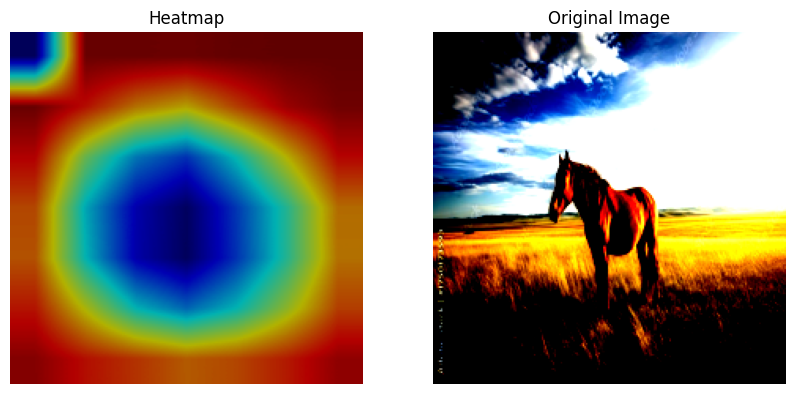

In [109]:
import matplotlib.pyplot as plt
image = image[0].permute(1, 2, 0)
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(heatmap)
axes[0].set_title("Heatmap")
axes[0].axis('off')
axes[1].imshow(image)
axes[1].set_title("Original Image")
axes[1].axis('off')
plt.show()